In [1]:
import matplotlib.pyplot as plt
import h5py
import glob
import numpy as np
from scipy import stats
from matplotlib.colors import LogNorm

In [2]:
%matplotlib widget

In [2]:
path = "packet-0060154-2025_11_20_07_55_40_CST.FLOW.hdf5"
f = h5py.File(path, "r")
files = sorted(glob.glob("data/*.FLOW.hdf5"))

In [3]:
def slice_from_ref_region(dset, ref_region_row):
    start = int(ref_region_row["start"])
    stop  = int(ref_region_row["stop"])
    return dset[start:stop]

In [4]:
##rock_muon
def get_track_segments(f, track_index):
    seg = f["analysis/rock_muon_segments/data"]
    rr  = f["analysis/rock_muon_tracks/ref/analysis/rock_muon_segments/ref_region"]
    return slice_from_ref_region(seg, rr[track_index])
##calib_hit    
def get_segment_hits(f, segment_index):
    hits = f["charge/calib_prompt_hits/data"]
    rr   = f["analysis/rock_muon_segments/ref/charge/calib_prompt_hits/ref_region"]
    return slice_from_ref_region(hits, rr[segment_index])
# quick check
#tracks = f["analysis/rock_muon_tracks/data"]
#segs0 = get_track_segments(f, 0)
#print("Track 0 event_id:", tracks[0]["event_id"], "nsegments:", len(segs0))
#print("Segment fields:", segs0.dtype.names)
#print("track fileds:", tracks.dtype.names)

In [5]:
def get_track_hits_via_segments(f, track_index, max_segments=None):
    # segments indices are implicit: segment_index corresponds to row in analysis/rock_muon_segments/data
    segs = get_track_segments(f, track_index)

    # We need the *indices* of these segments in the global segments table.
    # The segments slice we got is a copy of rows, not their original indices.
    # So: compute the global range using the same ref_region used for tracks->segments:
    rr_ts = f["analysis/rock_muon_tracks/ref/analysis/rock_muon_segments/ref_region"][track_index]
    seg_start = int(rr_ts["start"])
    seg_stop  = int(rr_ts["stop"])
    seg_indices = np.arange(seg_start, seg_stop, dtype=int)

    if max_segments is not None and len(seg_indices) > max_segments:
        seg_indices = seg_indices[:max_segments]

    all_hits = []
    for si in seg_indices:
        h = get_segment_hits(f, si)
        if len(h):
            all_hits.append(h)

    if not all_hits:
        return f["charge/calib_prompt_hits/data"][0:0]  # empty slice

    # concatenate structured arrays
    return np.concatenate(all_hits)

#hmu = get_track_hits_via_segments(f, 0)
#print("Muon-associated hits:", len(hmu))


In [6]:
def get_event_hits_by_event_index(f, event_index):
    hits = f["charge/calib_prompt_hits/data"]
    rr   = f["charge/events/ref/charge/calib_prompt_hits/ref_region"]
    return slice_from_ref_region(hits, rr[event_index])
def find_event_index_from_event_id(f, event_id):
    ev = f["charge/events/data"]
    # common patterns: either event_id matches ev["id"], or it’s just an index
    if "id" in ev.dtype.names:
        m = np.where(ev["id"] == event_id)[0]
        if len(m): 
            return int(m[0])
    # fallback: if event_id looks like an index
    if 0 <= int(event_id) < len(ev):
        return int(event_id)
    raise ValueError("Couldn't map rock_muon_tracks.event_id to charge/events")
    

In [7]:
def get_track_event_hits(f, track_index):
    tr = f["analysis/rock_muon_tracks/data"][track_index]
    ev_idx = find_event_index_from_event_id(f, tr["event_id"])
    return get_event_hits_by_event_index(f, ev_idx), ev_idx
    
def point_to_segment_distance(P, A, B):
    # P: (N,3) points; A,B: (3,) endpoints
    AB = B - A
    AP = P - A
    denom = np.dot(AB, AB)
    if denom == 0:
        return np.linalg.norm(P - A, axis=1)
    t = (AP @ AB) / denom
    t = np.clip(t, 0.0, 1.0)
    proj = A + t[:,None] * AB[None,:]
    return np.linalg.norm(P - proj, axis=1)
    
def find_near_muon_blips(f, track_index, r_core=5.0, r_near=30.0, qmin=0.0):
    tr = f["analysis/rock_muon_tracks/data"][track_index]
    all_hits, ev_idx = get_track_event_hits(f, track_index)

    if len(all_hits) == 0:
        return all_hits, all_hits, all_hits, ev_idx

    A = np.array([tr["x_start"], tr["y_start"], tr["z_start"]], dtype=float)
    B = np.array([tr["x_end"], tr["y_end"], tr["z_end"]], dtype=float)
    P = np.vstack([all_hits["x"], all_hits["y"], all_hits["z"]]).T

    d = point_to_segment_distance(P, A, B)
    Q = all_hits["Q"]
    goodQ = np.isfinite(Q) & (Q >= qmin)

    core = all_hits[goodQ & (d <= r_core)]
    near = all_hits[goodQ & (d > r_core) & (d <= r_near)]
    far  = all_hits[goodQ & (d > r_near)]

    return core, near, far, ev_idx

In [8]:
core_hits=[]
near_hits=[]
far_hits=[]
#print(len(files)) 
for fname in files:
    with h5py.File(fname, "r") as f:
        for track_index in range(len(f["analysis/rock_muon_tracks/data"])):
            tr = f["analysis/rock_muon_tracks/data"][track_index]
            core, near, far, ev_idx = find_near_muon_blips(f, track_index, r_core=5.0, r_near=30.0, qmin=0.0)
            if (len(core)) : core_hits.append(core)
            if (len(near)) : near_hits.append(near)
            if (len(far)) : far_hits.append(far)
       

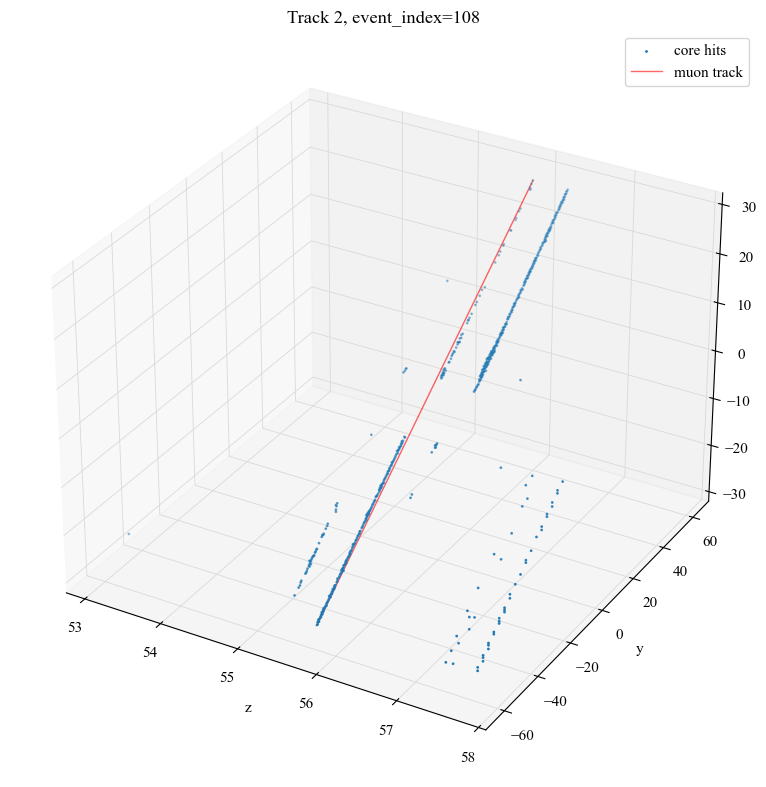

In [34]:
track_index = 2
tr = f["analysis/rock_muon_tracks/data"][track_index]
core_0, near, far, ev_idx = find_near_muon_blips(f, track_index, r_core=5.0, r_near=3.0, qmin=0.0)
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(core_0['z'], core_0['y'], core_0['x'], s=1,label='core hits')
ax.plot([tr["z_start"], tr["z_end"]], [tr["y_start"], tr["y_end"]],[tr["x_start"], tr["x_end"]], linewidth=1,color='red',alpha=0.6,label="muon track")
ax.grid(True)

for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
    axis._axinfo["grid"]["color"] = (0.85, 0.85, 0.85, 1.0)  
    axis._axinfo["grid"]["linewidth"] = 0.6
    axis._axinfo["grid"]["linestyle"] = "-"
ax.set_xlabel('z')
ax.set_ylabel('y')
ax.set_zlabel('x')
ax.set_title(f"Track {track_index}, event_index={ev_idx}")
ax.legend()
#ax.set_title(f'Event {i}')
plt.tight_layout()
plt.savefig("real_muon_track.png", dpi=600)
plt.show()

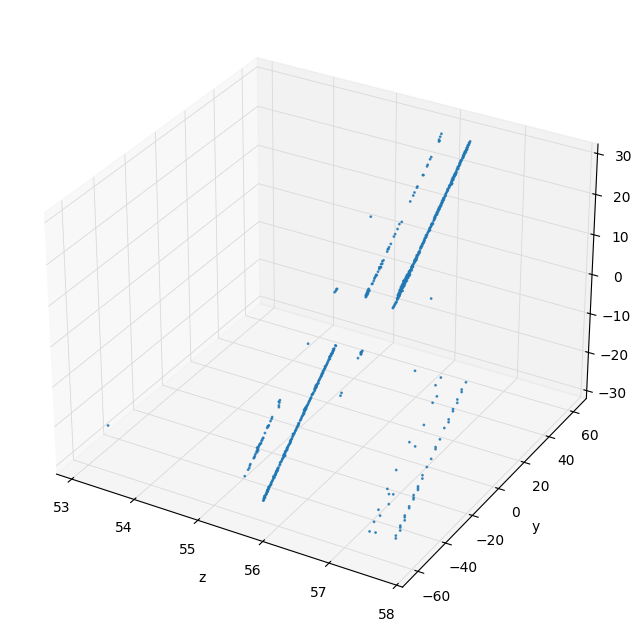

In [20]:
track_index = 2
core_12, near, far, ev_idx = find_near_muon_blips(f, track_index, r_core=5.0, r_near=3.0, qmin=12.0)
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(core_12['z'], core_12['y'], core_12['x'], s=1,alpha=0.8)

ax.grid(True)

for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
    axis._axinfo["grid"]["color"] = (0.85, 0.85, 0.85, 1.0)  
    axis._axinfo["grid"]["linewidth"] = 0.6
    axis._axinfo["grid"]["linestyle"] = "-"

ax.set_xlabel('z')
ax.set_ylabel('y')
ax.set_zlabel('x')
#ax.set_title(f'Event {i}')

plt.ion() 
plt.show()

In [13]:
def plot_core_vs_near(f, track_index, r_core=5.0, r_near=30.0, qmin=0.0):
    tr = f["analysis/rock_muon_tracks/data"][track_index]
    core, near, far, ev_idx = find_near_muon_blips(f, track_index, r_core, r_near, qmin)

    plt.figure()
    #if len(far):  plt.scatter(far["x"],  far["y"],  s=2, label="far")
    #if len(near): plt.scatter(near["x"], near["y"], s=6, label=f"near ({r_core}-{r_near})")
    if len(core): plt.scatter(core["x"], core["y"], s=10, label=f"core (<= {r_core})")

    plt.plot([tr["x_start"], tr["x_end"]], [tr["y_start"], tr["y_end"]], linewidth=2, label="track")
    plt.gca().set_aspect("equal", adjustable="box")
    plt.xlabel("x"); plt.ylabel("y")
    plt.title(f"Track {track_index}, event_index={ev_idx}, core={len(core)}, near={len(near)}")
    plt.legend()
    plt.show()

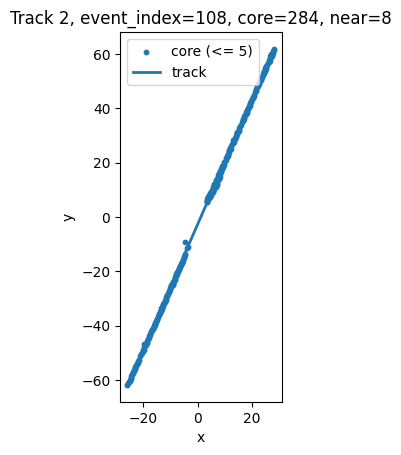

In [14]:
plot_core_vs_near(f,2,r_core=5, r_near=25, qmin=12.0)

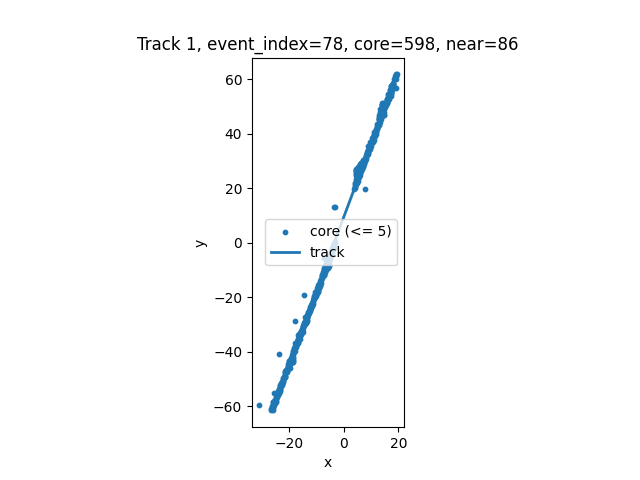

In [35]:
plot_core_vs_near(f,1,r_core=5, r_near=25, qmin=0.0)

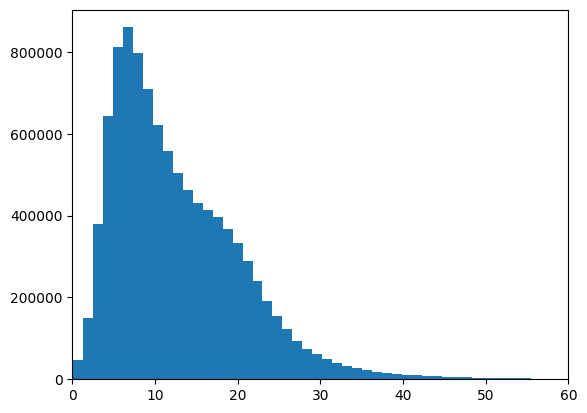

In [11]:
plt.hist(np.concatenate(core_hits)["Q_raw"],bins = 200)
#plt.yscale("log")
plt.xlim(0, 60)
plt.show()

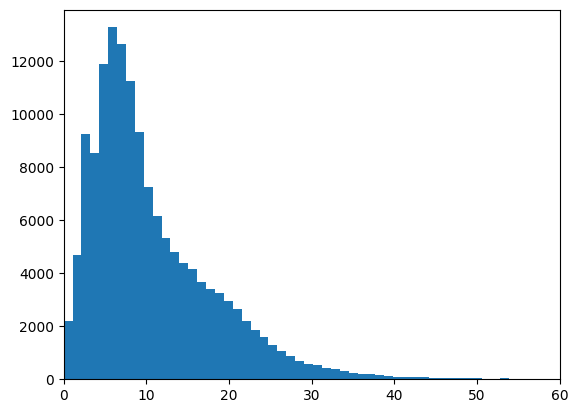

In [12]:
plt.hist(np.concatenate(far_hits)["Q"],bins = 200)
#plt.yscale("log")
plt.xlim(0, 60)
plt.show()

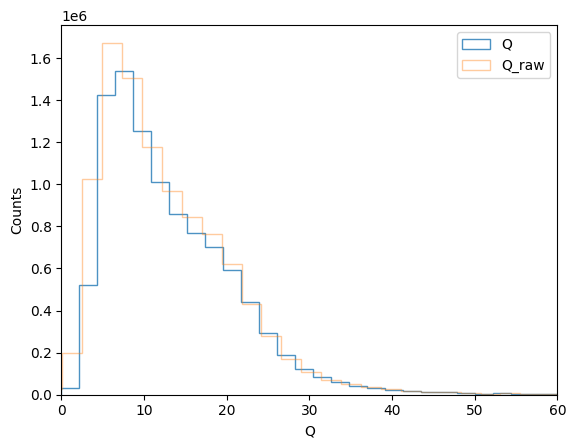

In [34]:
fig, ax = plt.subplots()
bins=100
ax.hist(np.concatenate(core_hits)["Q"], bins=bins, histtype="step",alpha=0.8, label="Q")
ax.hist(np.concatenate(core_hits)["Q_raw"], bins=bins,histtype="step", alpha=0.4, label="Q_raw")

ax.set_xlabel("Q")
ax.set_ylabel("Counts")
ax.legend()
ax.set_xlim(0,60)
plt.show()

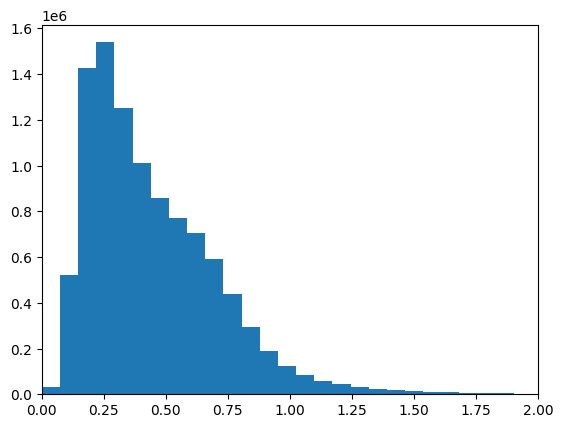

In [35]:
plt.hist(np.concatenate(core_hits)["E"],bins = 100)
#plt.yscale("log")
plt.xlim(0, 2)
plt.show()

In [9]:
def cum_Q(f,track_index,q_min):
    tr = f["analysis/rock_muon_tracks/data"][track_index]
    all_hits, _ = get_track_event_hits(f, track_index)
    if len(all_hits) == 0:
        return 0.0
    Q = all_hits["Q"]
    goodQ = np.isfinite(Q) & (Q >= q_min)
    return Q[goodQ].sum() 


In [11]:
tot_Q=[]
for fname in files:
    with h5py.File(fname, "r") as f:
        for track_index in range(len(f["analysis/rock_muon_tracks/data"])):
#    if (cum_Q(f,track_index,0)):
            tot_Q.append(cum_Q(f,track_index,0))

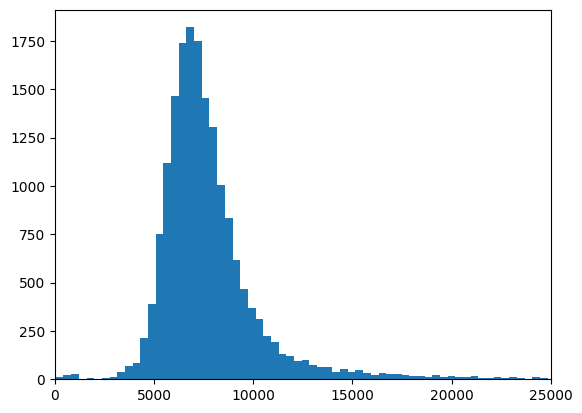

In [13]:
plt.hist(tot_Q,bins = 500)
#plt.yscale("log")
plt.xlim(0, 25000)
plt.show()

In [14]:
def cum_Q_by_event_index(f, event_index, q_min=0.0, q_field="Q"):
    hits = get_event_hits_by_event_index(f, event_index)

    if len(hits) == 0:
        return 0.0

    if q_field not in hits.dtype.names:
        raise KeyError(f"Field '{q_field}' not in hits. Available: {hits.dtype.names}")

    Q = hits[q_field]
    mask = np.isfinite(Q) & (Q >= q_min)
    return float(Q[mask].sum())
def cum_Q_by_event_id(f, event_id, q_min=0.0, q_field="Q"):
    event_index = find_event_index_from_event_id(f, event_id)
    return cum_Q_by_event_index(f, event_index, q_min=q_min, q_field=q_field)    

In [15]:
tot_Q_evt=[]
for fname in files:
    with h5py.File(fname, "r") as f:
        for evt_id in range(len(f["charge/events/data"])):
            tot_Q_evt.append(cum_Q_by_event_index(f,evt_id,0,"Q")) 

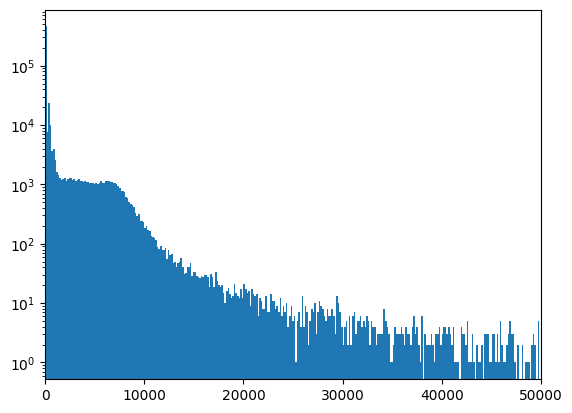

In [16]:
plt.hist(tot_Q_evt,bins = 10000)
plt.yscale("log")
plt.xlim(0, 50000)
plt.show()

In [17]:
def Occupancy_by_event_index(f, event_index, q_min=0.0, y='y',z='z',io_group=1):
    hits = get_event_hits_by_event_index(f, event_index)

    if len(hits) == 0:
        return np.array([]), np.array([]),np.array([])
    Q  = hits['Q']   
    yv = hits[y]
    zv = hits[z]
    mask = np.isfinite(Q) & (Q >= q_min) & (hits['io_group']==io_group)
    return yv[mask],zv[mask],Q[mask]

In [18]:
#evt_idx = 19126
q_min = 5.0
ymin= -61.85
ymax= 61.85
zmin= 2.68
zmax= 64.32
y_cum_1, z_cum_1 = [], []
y_cum_2, z_cum_2 = [], []

for fname in files:
    with h5py.File(fname, "r") as f:
        for evt_idx in range(len(f["charge/events/data"])):
            Q_tot = cum_Q_by_event_index(f, evt_idx, q_min, q_field="Q")
            if Q_tot < 1200:

        # io_group = 1
                y1, z1, Q1 = Occupancy_by_event_index(f, evt_idx, q_min, 'y', 'z', io_group=1)
                mask1 = (z1>=zmin) & (z1<=zmax) & (y1>=ymin) & (y1<=ymax)
                if np.any(mask1):
                    y_cum_1.append(y1[mask1])
                    z_cum_1.append(z1[mask1])

        # io_group = 2
                y2, z2, Q2 = Occupancy_by_event_index(f, evt_idx, q_min, 'y', 'z', io_group=2)
                mask2 = (z2>=zmin) & (z2<=zmax) & (y2>=ymin) & (y2<=ymax)
                if np.any(mask2):
                    y_cum_2.append(y2[mask2])
                    z_cum_2.append(z2[mask2])

# concatenate
y_cum_1 = np.concatenate(y_cum_1) if y_cum_1 else np.array([])
z_cum_1 = np.concatenate(z_cum_1) if z_cum_1 else np.array([])

y_cum_2 = np.concatenate(y_cum_2) if y_cum_2 else np.array([])
z_cum_2 = np.concatenate(z_cum_2) if z_cum_2 else np.array([])
#good = H[H > 0]
#cut = np.percentile(good, 99.5)  
#mask = 1
#mask = (H <= cut).astype(int)
#H_clean = H * mask


#plt.figure()
#cmap = plt.cm.viridis.copy()
#cmap.set_under("white")
#plt.imshow(H_clean.T, origin="lower", aspect="auto", extent=[zmin, zmax, ymin, ymax],norm=LogNorm(vmin=1))
#plt.colorbar(label="occupancy(log scale)")
#plt.xlabel("z")
#plt.ylabel("y")
#plt.show()

In [19]:
bins = [60, 120]

H1, zedges, yedges = np.histogram2d(
    z_cum_1, y_cum_1,
    bins=bins,
    range=[[zmin, zmax], [ymin, ymax]]
)

H2, _, _ = np.histogram2d(
    z_cum_2, y_cum_2,
    bins=bins,
    range=[[zmin, zmax], [ymin, ymax]]
)

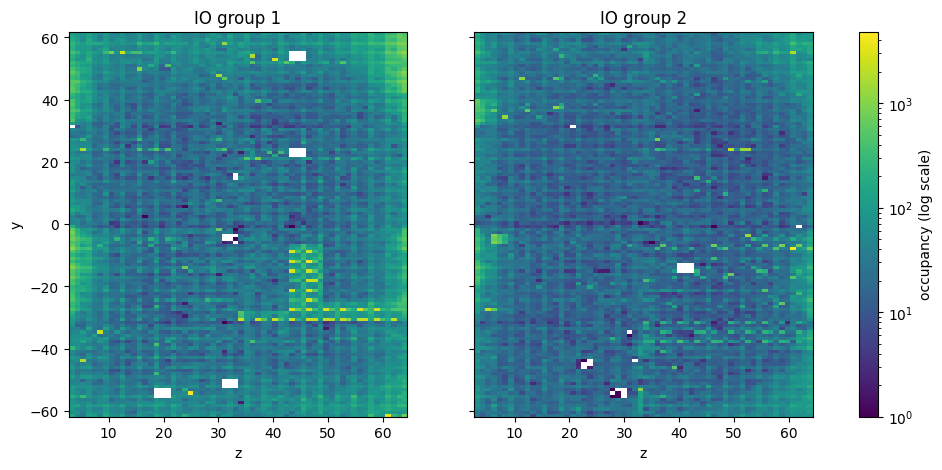

In [75]:
H1plot = H1.astype(float)
H2plot = H2.astype(float)

#H1plot[H1plot <= 0] = np.nan
#H2plot[H2plot <= 0] = np.nan

#cut1 = np.percentile(H1plot, 99.5)
#cut2 = np.percentile(H2plot, 99.5)
#mask = 1
#mask = (H <= cut).astype(int)
#H_clean = H * mask
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

im1 = axes[0].imshow(
    H1plot.T,
    origin="lower",
    aspect="auto",
    extent=[zmin, zmax, ymin, ymax],
    norm=LogNorm(vmin=1)
)
axes[0].set_title("IO group 1")
axes[0].set_xlabel("z")
axes[0].set_ylabel("y")

im2 = axes[1].imshow(
    H2plot.T,
    origin="lower",
    aspect="auto",
    extent=[zmin, zmax, ymin, ymax],
    norm=LogNorm(vmin=1)
)
axes[1].set_title("IO group 2")
axes[1].set_xlabel("z")

# one shared colorbar
cbar = fig.colorbar(im1, ax=axes.ravel().tolist())
cbar.set_label("occupancy (log scale)")

plt.show()


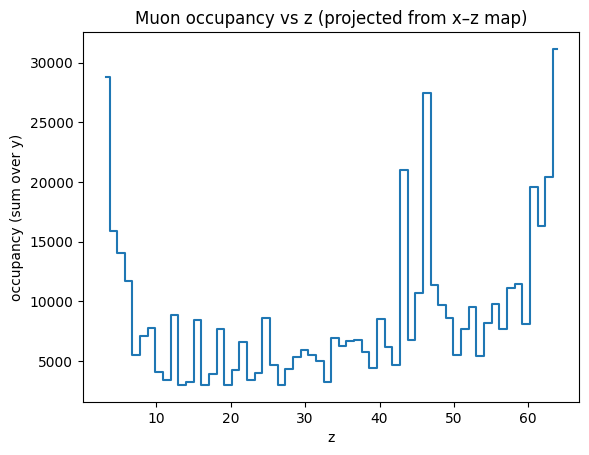

In [73]:
# H has shape (nz, ny) because you did histogram2d(z, y)
# z-projection = sum over y bins
Hz = H1plot.sum(axis=1)   # shape: (nz,)

# z bin centers
z_centers = 0.5 * (zedges[1:] + zedges[:-1])  

plt.figure()
plt.step(z_centers, Hz, where="mid")
plt.xlabel("z")
plt.ylabel("occupancy (sum over y)")
#plt.yscale("log")   # usually makes sense
plt.title("Muon occupancy vs z (projected from x–z map)")
plt.show()

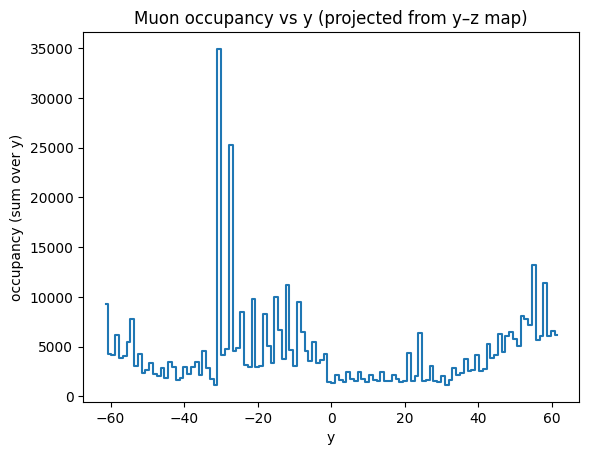

In [74]:
# H has shape (nz, ny) because you did histogram2d(z, y)
# z-projection = sum over y bins
Hy = H1plot.sum(axis=0)   # shape: (nz,)

# z bin centers
y_centers = 0.5 * (yedges[1:] + yedges[:-1])  # careful: you named them yedges but they are z-edges

plt.figure()
plt.step(y_centers, Hy, where="mid")
plt.xlabel("y")
plt.ylabel("occupancy (sum over y)")
#plt.yscale("log")   # usually makes sense
plt.title("Muon occupancy vs y (projected from y–z map)")
plt.show()

In [77]:
q_min = 5.0
ymin= -61.85
ymax= 61.85
zmin= -64.32
zmax= -2.68
y_cum_3, z_cum_3 = [], []
y_cum_4, z_cum_4 = [], []

for evt_idx in range(N_events):
    Q_tot = cum_Q_by_event_index(f, evt_idx, q_min, q_field="Q")
    if Q_tot < 1500:

        # io_group = 1
        y3, z3, Q3 = Occupancy_by_event_index(f, evt_idx, q_min, 'y', 'z', io_group=3)
        mask3 = (z3>=zmin) & (z3<=zmax) & (y3>=ymin) & (y3<=ymax)
        if np.any(mask3):
            y_cum_3.append(y3[mask3])
            z_cum_3.append(z3[mask3])

        # io_group = 2
        y4, z4, Q4 = Occupancy_by_event_index(f, evt_idx, q_min, 'y', 'z', io_group=4)
        mask4 = (z4>=zmin) & (z4<=zmax) & (y4>=ymin) & (y4<=ymax)
        if np.any(mask4):
            y_cum_4.append(y4[mask4])
            z_cum_4.append(z4[mask4])

# concatenate
y_cum_3 = np.concatenate(y_cum_3) if y_cum_3 else np.array([])
z_cum_3 = np.concatenate(z_cum_3) if z_cum_3 else np.array([])

y_cum_4 = np.concatenate(y_cum_4) if y_cum_4 else np.array([])
z_cum_4 = np.concatenate(z_cum_4) if z_cum_4 else np.array([])
#good = H[H > 0]
#cut = np.percentile(good, 99.5)  

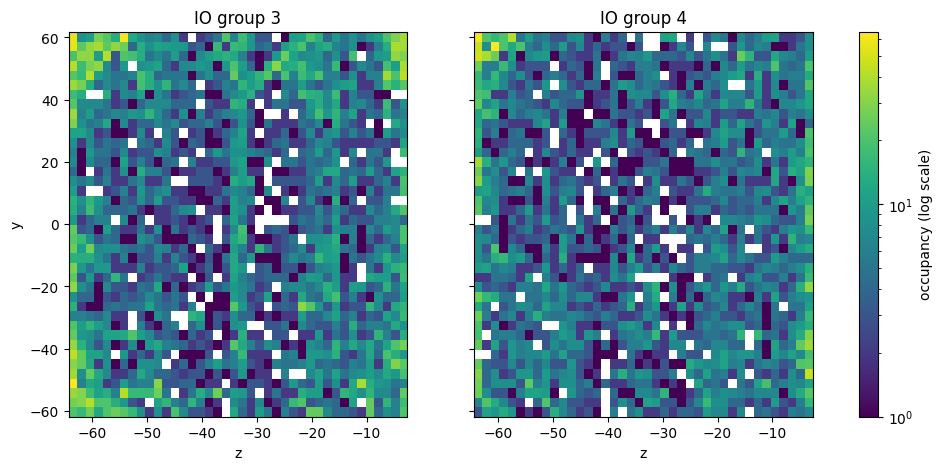

In [78]:
bins = [40, 40]

H3, zedges, yedges = np.histogram2d(
    z_cum_3, y_cum_3,
    bins=bins,
    range=[[zmin, zmax], [ymin, ymax]]
)

H4, _, _ = np.histogram2d(
    z_cum_4, y_cum_4,
    bins=bins,
    range=[[zmin, zmax], [ymin, ymax]]
)

H3plot = H3.astype(float)
H4plot = H4.astype(float)

#H1plot[H1plot <= 0] = np.nan
#H2plot[H2plot <= 0] = np.nan

#cut1 = np.percentile(H1plot, 99.5)
#cut2 = np.percentile(H2plot, 99.5)
#mask = 1
#mask = (H <= cut).astype(int)
#H_clean = H * mask
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

im3 = axes[0].imshow(
    H3plot.T,
    origin="lower",
    aspect="auto",
    extent=[zmin, zmax, ymin, ymax],
    norm=LogNorm(vmin=1)
)
axes[0].set_title("IO group 3")
axes[0].set_xlabel("z")
axes[0].set_ylabel("y")

im3 = axes[1].imshow(
    H4plot.T,
    origin="lower",
    aspect="auto",
    extent=[zmin, zmax, ymin, ymax],
    norm=LogNorm(vmin=1)
)
axes[1].set_title("IO group 4")
axes[1].set_xlabel("z")

# one shared colorbar
cbar = fig.colorbar(im3, ax=axes.ravel().tolist())
cbar.set_label("occupancy (log scale)")

plt.show()

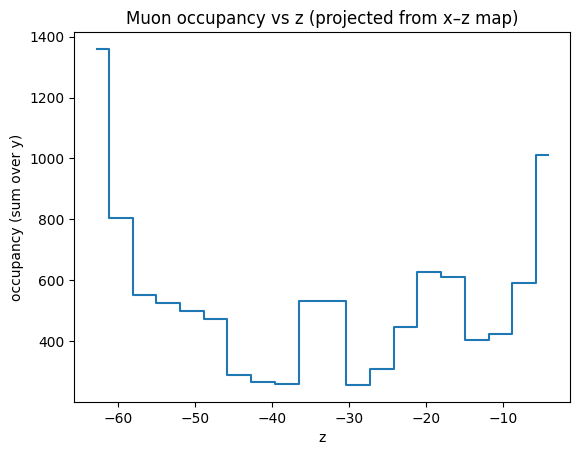

In [26]:
Hz = H3plot.sum(axis=1)   # shape: (nz,)

# z bin centers
z_centers = 0.5 * (zedges[1:] + zedges[:-1])  

plt.figure()
plt.step(z_centers, Hz, where="mid")
plt.xlabel("z")
plt.ylabel("occupancy (sum over y)")
#plt.yscale("log")   # usually makes sense
plt.title("Muon occupancy vs z (projected from x–z map)")
plt.show()

In [21]:
iz_hot, iy_hot = np.unravel_index(np.nanargmax(H1), H1.shape)

In [22]:
zlo, zhi = zedges[iz_hot], zedges[iz_hot+1]
ylo, yhi = yedges[iy_hot], yedges[iy_hot+1]
print(zlo)
print(zhi)
print(ylo)
print(yhi)

24.253999999999998
25.28133333333333
-54.63416666666667
-53.60333333333334


In [20]:
def select_hits_with_cuts(
    hits,
    q_min=0.0,
    y_range=None,   # (ymin,ymax)
    z_ranges=None,  # (zmin,zmax)
    hot_yz=None
):
    if len(hits) == 0:
        return np.zeros((0,), dtype=bool)

    Q = hits["Q"]
    mask = np.isfinite(Q) & (Q >= q_min)

    if y_range is not None:
        ymin, ymax = y_range
        mask &= (hits["y"] >= ymin) & (hits["y"] <= ymax)

    if z_ranges is not None:
        z_ok = np.zeros(len(hits), dtype=bool)
        for zmin, zmax in z_ranges:
            z_ok |= (hits["z"] >= zmin) & (hits["z"] <= zmax)
        mask &= z_ok

    if hot_yz is not None:
        ylo, yhi, zlo, zhi = hot_yz
        in_hot = (hits["y"] >= ylo) & (hits["y"] < yhi) & (hits["z"] >= zlo) & (hits["z"] < zhi)
        mask &= ~in_hot

    return mask

In [79]:
y_range=(-51.85,51.85)  # (ymin,ymax)
z_ranges=((12.68, 54.32), (-54.32, -12.68))  # (zmin,zmax)
hot_yz=(zlo,zhi,ylo,yhi)
two_hit_events = []

In [80]:
def signed_angle_two_hits(x,y, z):
    """
    y,z: length-2 arrays for the two hits in yz plane
    returns signed angle relative to +z axis
      - default: degrees in [-90, +90]
    """
    y = np.asarray(y); z = np.asarray(z);x = np.asarray(x);
    if len(y) != 2 or len(z) != 2 or len(x) !=2:
        raise ValueError("Need exactly 2 hits")

    #order = np.argsort(z)
    y1, y2 = y[0], y[1]
    z1, z2 = z[0], z[1]
    x1, x2 = x[0], x[1]
    r= np.sqrt((x2-x1)**2 + (y2-y1)**2 +(z2-z1)**2)
    theta_z = np.arccos((z2-z1) / r)

    theta_zx = np.arctan2((x2-x1), (z2-z1))
    theta_zy = np.arctan2((y2-y1), (z2-z1))
    return theta_z, theta_zx, theta_zy   
    #if abs(dz) < eps or abs(dy) < eps:
    #    return np.nan

    #theta = np.arctan2(dy, dz)  

    #if fold:
    #    theta = ((theta + np.pi/2) % np.pi) - np.pi/2

    #return theta

In [81]:
min_dist = 20.0  

two_hit_events = []
theta_z = []
theta_zx = []
theta_zy = []
for fname in files:
    with h5py.File(fname, "r") as f:
        for evt_idx in range(len(f["charge/events/data"])):
            hits = get_event_hits_by_event_index(f, evt_idx)
            Q_tot = cum_Q_by_event_index(f, evt_idx, q_min=5, q_field="Q")
            if Q_tot < 2000:
                keep = select_hits_with_cuts(
                    hits,
                    q_min=5,
                    y_range=y_range,
                    z_ranges=z_ranges,
                    hot_yz=hot_yz
                )

                if np.count_nonzero(keep) != 2:
                    continue

                y2 = hits["y"][keep]
                z2 = hits["z"][keep]
                x2 = hits["x"][keep]
                dy = y2[1] - y2[0]
                dz = z2[1] - z2[0]
                dx = x2[1] - x2[0]
                dist = np.sqrt(dy**2 + dz**2 + dx**2)   # sqrt(dy^2 + dz^2)

                if dist < min_dist:
                    continue  


                two_hit_events.append(evt_idx)

                z,zx,zy = signed_angle_two_hits(x2,y2, z2)

                
                theta_z.append(z)
                theta_zx.append(zx)
                theta_zy.append(zy)

theta_z = np.array(theta_z)
theta_zx = np.array(theta_zx)
theta_zy = np.array(theta_zy)
#print("N clean 2-hit events:", len(two_hit_events))
#print("angle range:", angles.min(), angles.max())

In [71]:
print(len(theta_zx))

64754


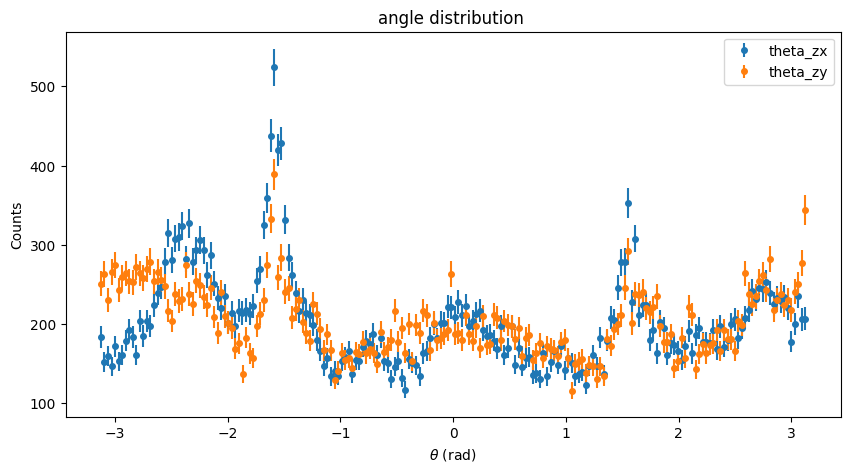

In [83]:
nbins = 200
#theta_min = -np.pi/2
#theta_max = +np.pi/2
def plot_angle(data):
    counts, edges = np.histogram(data, bins=nbins)
    centers = 0.5 * (edges[1:] + edges[:-1])
    bin_width = edges[1] - edges[0]
    err = np.sqrt(counts)
    return counts,centers,bin_width,err
#wi is 1/sigma^2
#y_avg = sum wiyi/sum wi = N_bin/sum wi
#y_err = sqrt(1/sum wi)
#mask = yerr > 0
#w = 1.0 / (yerr[mask]**2)          # inverse-variance weights
#ybar = np.sum(w * counts[mask]) / np.sum(w)
#ybar_err = np.sqrt(1.0 / np.sum(w))

#print("weighted mean =", ybar, "+/-", ybar_err)

plt.figure(figsize=(10,5))
counts_zx,centers_zx,bin_width_zx,err_zx = plot_angle(theta_zx)
counts_zy,centers_zy,bin_width_zy,err_zy = plot_angle(theta_zy)

#plt.axhline(ybar, linewidth=2, linestyle='--', color='red',label=f'weighted mean = {ybar:.2f}')

plt.errorbar(
    centers_zx, counts_zx,
    yerr=err_zx,
    fmt='o',            # points
    markersize=4,      # make points small
   label='theta_zx'
)
plt.errorbar(
    centers_zy, counts_zy,
    yerr=err_zy,
    fmt='o',            # points
    markersize=4,      # make points small
   label='theta_zy'
)
plt.xlabel(r"$\theta$ (rad)")
plt.ylabel("Counts")
plt.title("angle distribution ")
#plt.xlim(theta_min-.1, theta_max+.1)
#plt.ylim(0, 10000)
#plt.grid(alpha=0.3)
plt.legend()
#plt.tight_layout()
plt.show()

In [29]:
N_spills = 258000
N_off_used = 19127
w_bkg = N_spills / N_off_used 
bkg_counts_scaled = counts * w_bkg
bkg_err_scaled    = yerr    * w_bkg  

weighted mean = 238.10628930829662 +/- 10.34692330995478


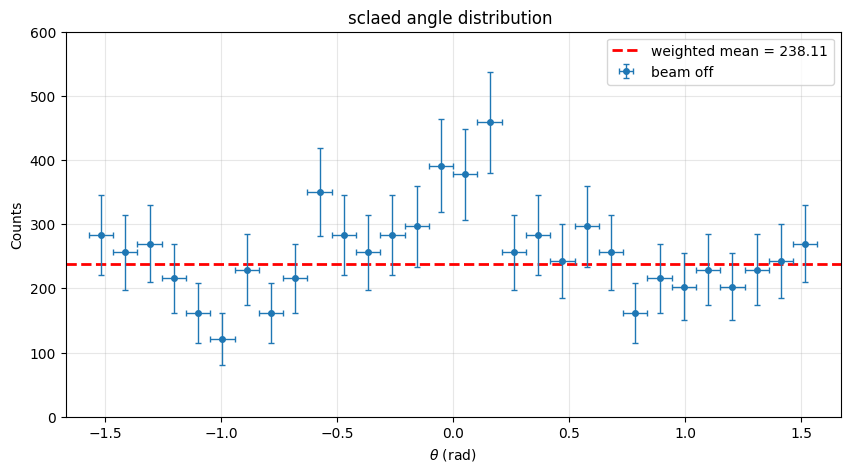

In [51]:
mask = yerr > 0
w = 1.0 / (bkg_err_scaled[mask]**2)          # inverse-variance weights
ybar = np.sum(w * bkg_counts_scaled[mask]) / np.sum(w)
ybar_err = np.sqrt(1.0 / np.sum(w))

print("weighted mean =", ybar, "+/-", ybar_err)

plt.figure(figsize=(10,5))

plt.axhline(ybar, linewidth=2, linestyle='--', color='red',label=f'weighted mean = {ybar:.2f}')

plt.errorbar(
    centers, bkg_counts_scaled,
    yerr=bkg_err_scaled ,
    xerr=bin_width/2,
    fmt='o',            # points
    markersize=4,      # make points small
    capsize=2,         # little caps on error bars
    elinewidth=1,
   label='beam off'
)

plt.xlabel(r"$\theta$ (rad)")
plt.ylabel("Counts")
plt.title("sclaed angle distribution ")
plt.xlim(theta_min-.1, theta_max+.1)
plt.ylim(0, 600)

plt.grid(alpha=0.3)
plt.legend()
plt.show()

In [54]:
def gauss(x, A, mu, sigma):
    return A * np.exp(-(x - mu)**2 / (2 * sigma**2))

In [55]:
x = np.linspace(theta_min, theta_max, 500)
A=2647.7216648114527
mu=-0.00384395056035265
sigma=0.07045680343088262
y = gauss(x, A,mu,sigma)

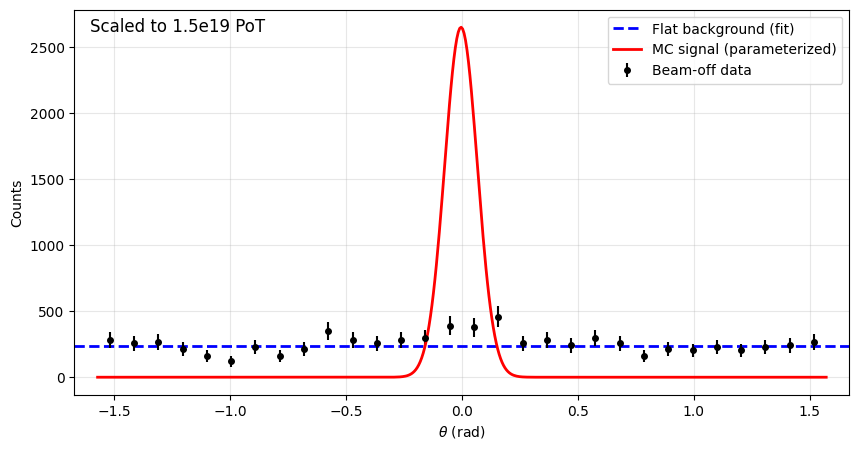

In [67]:
plt.figure(figsize=(10,5))

plt.axhline(ybar, linewidth=2, linestyle='--', color='b',label='Flat background (fit)')

plt.errorbar(
    centers, bkg_counts_scaled,
    yerr=bkg_err_scaled ,
    #xerr=bin_width/2, 
    markersize=4,
    fmt="o",
    color="k",
    #capsize=2,         
    #elinewidth=1,
   label='Beam-off data'
)
plt.plot(x, y, 'r-', lw=2, 
         label='MC signal (parameterized)'
               )
plt.xlabel(r"$\theta$ (rad)")
plt.ylabel("Counts")
#plt.title("sclaed angle distribution ")
plt.xlim(theta_min-.1, theta_max+.1)
#plt.ylim(0, 600)

plt.text(
    0.02, 0.98,                  # x, y in axes fraction
    "Scaled to 1.5e19 PoT",
    transform=plt.gca().transAxes,
    ha="left",
    va="top",
    fontsize=12
)


plt.grid(alpha=0.3)
plt.legend()
plt.savefig("angle_distribution.png", dpi=300)
plt.show()

In [46]:
N_spills = 258000
N_off_used = 19127
w_bkg = N_spills / N_off_used 
print(76*w_bkg)

1025.1476969728656


In [68]:
def NumOfEvt(qmin,min_dist):
    two_hit_events = []
    for evt_idx in range(N_events):
        hits = get_event_hits_by_event_index(f, evt_idx)
        Q_tot = cum_Q_by_event_index(f, evt_idx, q_min=qmin, q_field="Q")
        if Q_tot < 1500:
            keep = select_hits_with_cuts(
                hits,
                q_min=qmin,
                y_range=y_range,
                z_ranges=z_ranges,
                hot_yz=hot_yz
            )

            if np.count_nonzero(keep) != 2:
                continue

            y2 = hits["y"][keep]
            z2 = hits["z"][keep]

            dy = y2[1] - y2[0]
            dz = z2[1] - z2[0]
            dist = np.hypot(dy, dz)   # sqrt(dy^2 + dz^2)

            if dist < min_dist:
                continue  


            two_hit_events.append(evt_idx)
    return len(two_hit_events)

In [71]:
Evts=[]
for i in range(21):
    Evts.append(NumOfEvt(i*0.5,20))
print(Evts)    

[1082, 1082, 1082, 1082, 1059, 992, 881, 775, 678, 613, 573, 556, 514, 498, 478, 465, 475, 483, 467, 447, 447]


<ErrorbarContainer object of 3 artists>

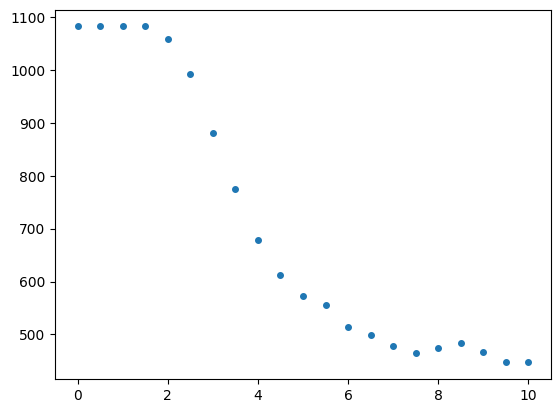

In [75]:
x = np.arange(21) * 0.5   
y = np.array(Evts) 
#yerr = np.sqrt(y)
plt.errorbar(
    x, y,
#    yerr=yerr,
    fmt='o',
    markersize=4,
    linestyle='none'
)

In [72]:
Evts_dis=[]
for i in range(11):
    Evts_dis.append(NumOfEvt(0,i*10))
print(Evts_dis)   

[1869, 1270, 1082, 904, 783, 667, 519, 372, 219, 92, 26]


<ErrorbarContainer object of 3 artists>

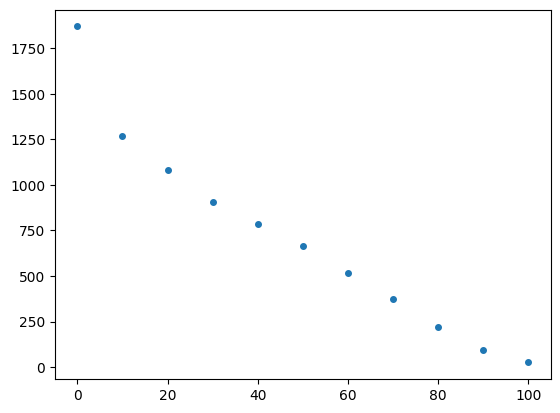

In [74]:
x = np.arange(11) * 10   
y = np.array(Evts_dis)       
plt.errorbar(
    x, y,
    fmt='o',
    markersize=4,
    linestyle='none'
)

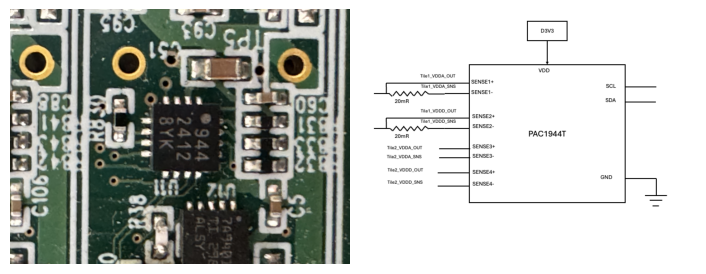

In [37]:
mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "STIXGeneral", "DejaVu Serif"],
    "mathtext.fontset": "stix",
    "font.size": 11,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

imgA = mpimg.imread("ADC.jpeg")
imgB = mpimg.imread("pac1944.png")

fig = plt.figure(figsize=(7.0, 2.8), facecolor="white")
gs = fig.add_gridspec(1, 2, wspace=0.02, left=0.01, right=0.99, bottom=0.01, top=0.99)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])

ax1.imshow(imgA); ax1.axis("off")
ax2.imshow(imgB); ax2.axis("off")

#fig.text(0.015, 0.985, "(a)", ha="left", va="top", fontsize=18, fontweight="bold")
#fig.text(0.515, 0.985, "(b)", ha="left", va="top", fontsize=18, fontweight="bold")

#fig.savefig("fig_two_panel_aligned.pdf", bbox_inches="tight", pad_inches=0.0)
fig.savefig("pac1944_bd.png", dpi=1200, bbox_inches="tight", pad_inches=0.0)
plt.show()